## Test Script to test .h5 model
### 🎯確認建立的模型可以：
- 被 load_model() 正確讀取
- input shape 符合老師的 reshape 規則
- 在 MNIST test set 上正常跑出 accuracy
- 沒有 runtime error（老師測試環境會這樣跑）

In [1]:
import numpy as np
import os
from tensorflow.keras.models import load_model

# Show current working directory
print("Current working directory:", os.getcwd())

# Load the last .h5 file found
net = None
for file in os.listdir(os.getcwd()):
    if file.endswith(".h5"):
        print("Found model file:", file)
        net = load_model(file)

# Check model loaded
if net is None:
    raise RuntimeError("No .h5 model file found in current directory!")

net.summary()

# Determine model type
input_dims = net.input_shape
netType = 'CNN' if len(input_dims) > 2 else 'MLP'
print("Detected network type:", netType)

# Load MNIST
from tensorflow.keras.datasets import mnist
(x_train, labels_train), (x_test, labels_test) = mnist.load_data()

# Normalize
x_test = x_test.astype('float32') / 255.0

# Reshape based on model type
if netType == 'MLP':
    x_test = x_test.reshape(10000, 784)
else:
    x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Predict
outputs = net.predict(x_test)
labels_predicted = np.argmax(outputs, axis=1)

# Accuracy
correct_classified = np.sum(labels_predicted == labels_test)
print('Percentage correctly classified MNIST =',
      100 * correct_classified / labels_test.size)


Current working directory: /Users/wangku/Documents/KCL/CourseWork/Pattern Recognition
Found model file: cw1_mnist_cnn_tf218.h5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 871,020 (3.32 MB)

 Trainable params: 870,826 (3.32 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 2 (12.00 B)

Detected network type: CNN
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Percentage correctly classified MNIST = 99.65


## Error Analysis (Misclassified Samples)
### 🎯 這不是在測準確率，而是在做 錯誤分析（error analysis）：
- 找出模型分錯的圖片 misclassified_indices = np.where(labels_predicted != labels_test)[0]
- 把「錯的圖片」畫出來
- 畫出該圖片的「預測機率分佈」
> The following figure shows examples of misclassified MNIST digits and the corresponding predicted probability distributions.
Most misclassifications occur for visually ambiguous digits (e.g., 4 vs 9, 3 vs 5), indicating the model confusion arises from intrinsic ambiguity in the data rather than systematic model failure.


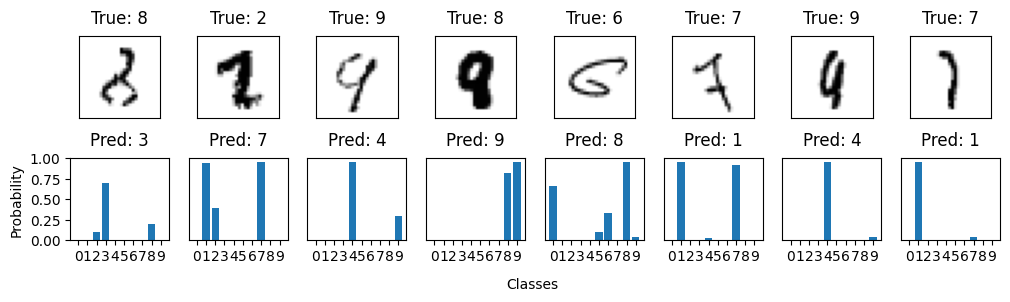

In [2]:
# Find and plot some misclassified samples
misclassified_indices = np.where(labels_predicted != labels_test)[0]
n_plot = min(len(misclassified_indices), 8)

import matplotlib.pyplot as plt

if n_plot > 0:
    fig, axes = plt.subplots(2, n_plot, figsize=(12, 3))
    fig.subplots_adjust(hspace=0.5)

    for i in range(n_plot):
        idx = misclassified_indices[i]

        # Show image
        axes[0, i].imshow(x_test[idx].reshape(28, 28), cmap='gray_r')
        axes[0, i].set_title(f'True: {labels_test[idx]}', y=1.05)
        axes[0, i].get_xaxis().set_visible(False)
        axes[0, i].get_yaxis().set_visible(False)

        # Predict single sample
        if netType == 'MLP':
            output = net.predict(x_test[idx:idx+1].reshape(1, 784), verbose=0)
        else:
            output = net.predict(x_test[idx:idx+1].reshape(1, 28, 28, 1), verbose=0)

        output = output[0]

        axes[1, i].bar(range(10), output)
        axes[1, i].set_xticks(range(10))
        axes[1, i].set_title(f'Pred: {np.argmax(output)}', y=1.05)
        axes[1, i].get_yaxis().set_visible(False)

        if i == 0:
            axes[1, i].get_yaxis().set_visible(True)
            axes[1, 0].set_ylabel('Probability')
            axes[1, 0].set_yticks([0, 0.25, 0.5, 0.75, 1])

    fig.subplots_adjust(bottom=0.2)
    fig.text(0.51, 0.05, 'Classes', ha='center', va='center')
    plt.savefig("misclassified.pdf")
    plt.show()
else:
    print("No misclassified samples found. No plot generated.")